In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda')

In [2]:
from minimodel import data
mouse_id = 4

data_path = '/media/carsen/ssd1/minimodel/data'
weight_path = '../weights'
np.random.seed(1)

In [3]:
# load neurons
fname = '%s_nat60k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all, iplanes = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id, return_iplane=True)
n_stim, n_neurons = spks.shape


loading activities from /media/carsen/ssd1/minimodel/data/FX8_nat60k_2023_05_16.npz


In [4]:
# load catvar result

res = np.load(f'/media/carsen/ssd1/approxineuro/figures/outputs/catvar_{data.mouse_names[mouse_id]}_oneshot_result.npz')
ineurons = res['valid_ineurons']
model_fecv = res['model_catvar']
pred_fecv = res['pred_catvar'] 
channel_corr = res['mean_correlation']
neural_fecv = res['neural_catvar']
iplanes = iplanes[ineurons]

In [5]:
layers = np.zeros(iplanes.shape)
layers[iplanes==0] = 2
layers[iplanes==1] = 1
layers[iplanes==2] = 2
layers[iplanes==3] = 1

In [13]:
neural_fecv.shape

(5804,)

In [14]:
model_fecv.shape

(1079, 9)

iplane 0: 344 neurons, mean: 0.03078646099830847, std: 0.0014541201337495045
iplane 1: 176 neurons, mean: 0.04852392447346444, std: 0.002528306953166331
iplane 2: 352 neurons, mean: 0.024989417810563408, std: 0.0012380418171750202
iplane 3: 207 neurons, mean: 0.04470370386699729, std: 0.002961881694488305


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_ylim'

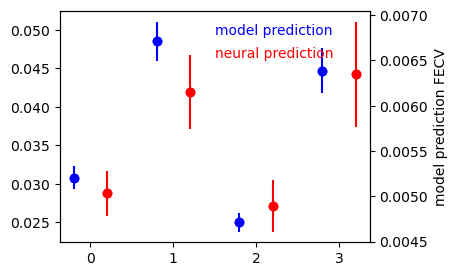

In [17]:
means = []
sems = []
neural_means = []
neural_sems = []
fig, ax = plt.subplots(1,1,figsize=(4,3))
for i in range(4):
    idxes = np.where(iplanes == i)[0]
    means.append(np.mean(pred_fecv[idxes]))
    sems.append(np.std(pred_fecv[idxes])/np.sqrt(len(idxes)))
    neural_means.append(np.mean(neural_fecv[ineurons[idxes]]))
    neural_sems.append(np.std(neural_fecv[ineurons[idxes]])/np.sqrt(len(idxes)))
    print(f'iplane {i}: {len(idxes)} neurons, mean: {means[-1]}, std: {sems[-1]}')
    # plt.scatter(i*np.ones(len(idxes))-0.2, pred_fecv[idxes], color = 'gray', s=1)
    # plt.plot(i*np.ones(len(idxes)), pred_fecv[idxes], 'x', color = 'gray', alpha = 0.1)
x = np.arange(4)
plt.plot(x-0.2, means, 'o', color = 'blue', label = 'model prediction')
plt.errorbar(x-0.2, means, yerr=sems, fmt='o', color = 'blue')
# twin axis
ax2 = ax.twinx()
ax2.plot(x+0.2, neural_means, 'o', color = 'red', label = 'neural prediction')
ax2.errorbar(x+0.2, neural_means, yerr=neural_sems, fmt='o', color = 'red')
plt.xlabel('iplane')
plt.ylabel('model prediction FECV')
plt.xticks(range(4))
ax.text(0.5, 0.9, 'model prediction', color = 'blue', transform=ax.transAxes)
ax2.text(0.5, 0.8, 'neural prediction', color = 'red', transform=ax.transAxes)
plt.set_ylim([0, 0.06])
plt.show()

Ttest_indResult(statistic=9.49618503492963, pvalue=1.3551751284113904e-20)


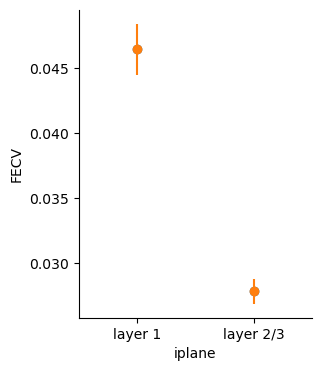

In [136]:
# layer 1 versus layer 2
means = []
sems = []
fig, ax = plt.subplots(1,1,figsize=(3,4))
for i in range(2):
    idxes = np.where(layers== (i+1))[0]
    means.append(np.mean(pred_fecv[idxes]))
    sems.append(np.std(pred_fecv[idxes])/np.sqrt(len(idxes)))
    # plt.plot(i*np.ones(len(idxes)), pred_fecv[idxes], 'x', color = 'gray', alpha = 0.01)
plt.plot([0, 1], [means[0], means[1]], 'o')
plt.errorbar(range(2), means, yerr=sems, fmt='o')
plt.xlabel('iplane')
# statistical test
from scipy.stats import ttest_ind
print(ttest_ind(pred_fecv[layers==1], pred_fecv[layers==2]))
plt.ylabel('model prediction FECV')
plt.xticks(range(2), ['layer 1', 'layer 2/3'])
plt.xlim(-0.5, 1.5)
# set top and right axis to be invisible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [137]:
dat = np.load(f'/media/carsen/ssd1/approxineuro/figures/outputs/minimodel_{data.mouse_names[mouse_id]}_result.npz', allow_pickle=True)
Wx = dat['wx_all']
Wy = dat['wy_all']
feve = dat['feve_all']
high_feve_idxes = np.where(feve > 0.7)[0]

from minimodel.utils import weight_bandwidth
Wxy = np.einsum('ij,ik->ijk', Wy, Wx)
NN = Wxy.shape[0]
bandwidth_Wx = np.zeros(NN)
bandwidth_Wy = np.zeros(NN)
for i in range(NN):
    bandwidth_Wx[i] = weight_bandwidth(Wx[i, :])
    bandwidth_Wy[i] = weight_bandwidth(Wy[i, :])
rf_size = bandwidth_Wx * bandwidth_Wy
rf_size = rf_size[high_feve_idxes]

/tmp/ipykernel_861814/604408947.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')


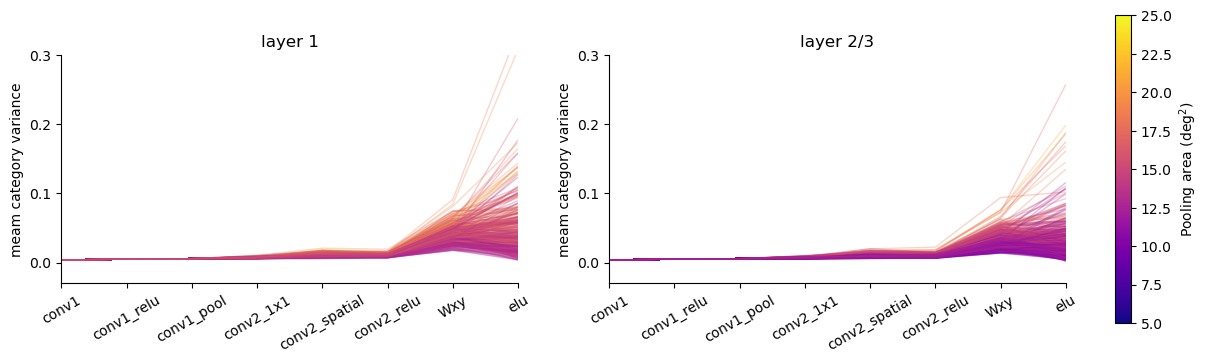

In [138]:
idxes = np.where(layers==1)[0]
rfsize = rf_size[idxes]
rfsize = np.pi * rfsize * (270/264) * (65/66)
minimodel_catvar_all = model_fecv[idxes]
op_all = ['conv1', 'conv1_relu', 'conv1_pool', 'conv2_1x1', 'conv2_spatial', 'conv2_relu', 'Wxy', 'elu']

# set font size
# rf_size_deg = (np.sqrt(rfsize)*2) * 270/264
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
# cmap = plt.cm.get_cmap('plasma_r')
import seaborn as sns
# cmap = sns.color_palette('magma', as_cmap=True)
cmap = plt.cm.get_cmap('plasma')
vmax = 25 # 600
vmin = 5
labels = ['layer 1', 'layer 2/3']
for k in range(2):
    ax = axs[k]

    idxes = np.where(layers==(k+1))[0]
    rfsize = rf_size[idxes]
    rfsize = np.sqrt(rfsize* (270/264)*(65/66)) * 2
    minimodel_catvar_all = model_fecv[idxes]
    rfsize_normalized = (rfsize - vmin) / (vmax - vmin)
    colors = [cmap(rfsize_normalized[i]) for i in range(len(rfsize_normalized))]
    NN = len(rfsize)
    # for i in range(NN):
    #     ax.plot(minimodel_catvar_all[i], 'o-', alpha=0.1, color=cmap((rfsize[i])/600),markersize=2)
    segments = [np.column_stack([np.arange(minimodel_catvar_all.shape[1]), minimodel_catvar_all[i]]) for i in range(NN)]
    colors = [cmap(rfsize_normalized[i]) for i in range(len(rfsize_normalized))]

    # Create a LineCollection from the segments and set the colors
    from matplotlib.collections import LineCollection
    lc = LineCollection(segments, colors=colors, linewidths=1, alpha=0.3, rasterized=True)
    ax.add_collection(lc)

    ax.set_xticks(np.arange(len(op_all)), op_all, rotation=30)                                      
    ax.set_ylabel('meam category variance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    
    ax.set_ylim(-0.03, 0.3)
    ax.set_yticks([0, 0.1, 0.2, 0.3])
    ax.set_aspect(0.5/ax.get_data_ratio())
    ax.set_title(f'{labels[k]}')
    if k>0:
        # cbar = fig.colorbar(sm, ax=ax, alpha=1, pad=0.04)
        # cbar.set_label('Pooling area (deg$^2$)')
        # add cbar outside both axes
        cbar = fig.colorbar(sm, ax=axs, alpha=1, pad=0.04)
        cbar.set_label('Pooling area (deg$^2$)')

Ttest_indResult(statistic=9.496185858345532, pvalue=1.355165244653438e-20)


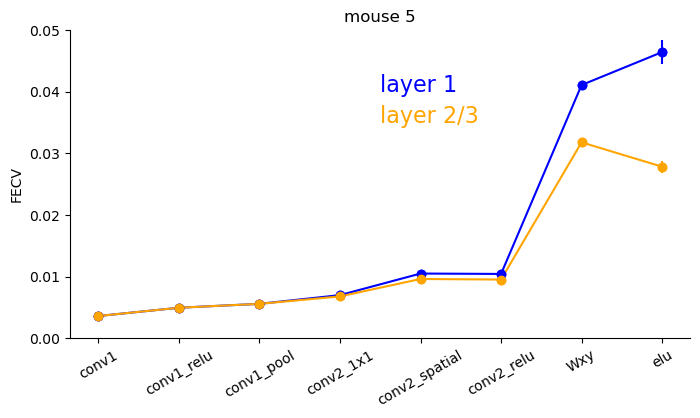

In [139]:
# mean correlation
# layer 1 versus layer 2
means_l1 = []
sems_l1 = []
means_l2 = []
sems_l2 = []
fig, ax = plt.subplots(1,1,figsize=(8,4))
nvalues = 8
for k in range(nvalues):
    x = model_fecv[:, k]
    idxes = np.where(layers== 1)[0]
    means_l1.append(np.mean(x[idxes]))
    sems_l1.append(np.std(x[idxes])/np.sqrt(len(idxes)))
    idxes = np.where(layers== 2)[0]
    means_l2.append(np.mean(x[idxes]))
    sems_l2.append(np.std(x[idxes])/np.sqrt(len(idxes)))
    # plt.plot(i*np.ones(len(idxes)), pred_fecv[idxes], 'x', color = 'gray', alpha = 0.01)
plt.plot(np.arange(nvalues), means_l1, '-o', label='layer 1', color='blue')
plt.errorbar(np.arange(nvalues), means_l1, yerr=sems_l1, fmt='o', color='blue')
plt.plot(np.arange(nvalues), means_l2, '-o', label='layer 2/3', color='orange')
plt.errorbar(np.arange(nvalues), means_l2, yerr=sems_l2, fmt='o', color='orange')
# statistical test
from scipy.stats import ttest_ind
print(ttest_ind(x[layers==1], x[layers==2]))
plt.ylabel('FECV')
# plt.xticks(range(2), ['layer 1', 'layer 2/3'])
# plt.xlim(-0.5, 1.5)
# set top and right axis to be invisible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(range(nvalues), op_all, rotation=30)
ax.text(0.5, 0.8, 'layer 1', color='blue', transform=ax.transAxes, fontsize=16)
ax.text(0.5, 0.7, 'layer 2/3', color='orange', transform=ax.transAxes, fontsize=16)
ax.set_title(f'mouse {mouse_id+1}')
ax.set_ylim(0, 0.05)
plt.show()

Ttest_indResult(statistic=15.984608866405651, pvalue=9.040414568954843e-52)


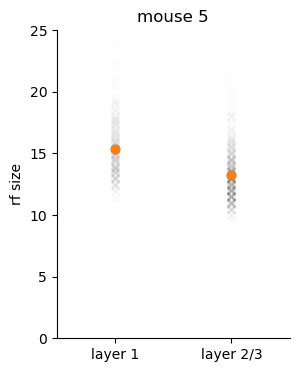

In [140]:
# rf size
# layer 1 versus layer 2
means = []
sems = []
x = np.sqrt(rf_size* (270/264)*(65/66)) * 2
fig, ax = plt.subplots(1,1,figsize=(3,4))
for i in range(2):
    idxes = np.where(layers== (i+1))[0]
    means.append(np.mean(x[idxes]))
    sems.append(np.std(x[idxes])/np.sqrt(len(idxes)))
    plt.plot(i*np.ones(len(idxes)), x[idxes], 'x', color = 'gray', alpha = 0.01)
plt.plot([0, 1], [means[0], means[1]], 'o')
plt.errorbar(range(2), means, yerr=sems, fmt='o')
# statistical test
from scipy.stats import ttest_ind
print(ttest_ind(x[layers==1], x[layers==2]))
plt.ylabel('rf size')
plt.xticks(range(2), ['layer 1', 'layer 2/3'])
plt.xlim(-0.5, 1.5)
# set top and right axis to be invisible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 25)
ax.set_title(f'mouse {mouse_id+1}')
plt.show()

Ttest_indResult(statistic=-4.600552014549126, pvalue=4.714070377623508e-06)


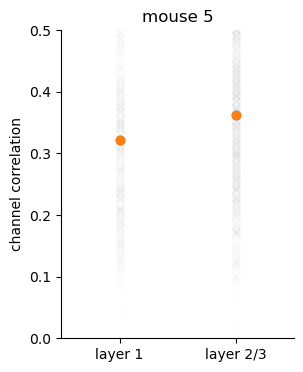

In [141]:
# mean correlation
# layer 1 versus layer 2
means = []
sems = []
x = channel_corr
fig, ax = plt.subplots(1,1,figsize=(3,4))
for i in range(2):
    idxes = np.where(layers== (i+1))[0]
    means.append(np.mean(x[idxes]))
    sems.append(np.std(x[idxes])/np.sqrt(len(idxes)))
    plt.plot(i*np.ones(len(idxes)), x[idxes], 'x', color = 'gray', alpha = 0.01)
plt.plot([0, 1], [means[0], means[1]], 'o')
plt.errorbar(range(2), means, yerr=sems, fmt='o')
# statistical test
from scipy.stats import ttest_ind
print(ttest_ind(x[layers==1], x[layers==2]))
plt.ylabel('channel correlation')
plt.xticks(range(2), ['layer 1', 'layer 2/3'])
plt.xlim(-0.5, 1.5)
# set top and right axis to be invisible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 0.5)
ax.set_title(f'mouse {mouse_id+1}')
plt.show()